Библиотеки загружены ✅
1. Загрузка данных
Размер датасета: (12294, 7)

A) Быстрый обзор данных
Первые и последние строки:


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,GintamaÂ°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262


,anime_id,name,genre,type,episodes,rating,members
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.46,142



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB
None

Статистика числовых колонок:


,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06



Статистика категориальных колонок:


,name,genre,type,episodes
count,12294,12232,12269,12294
unique,12292,3264,6,187
top,Saru Kani Gassen,Hentai,TV,1
freq,2,823,3787,5677



Пропущенные значения:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Дубликаты: 0

B) Обработка пропусков
Заполнили пропуски в episodes медианой = 2.0
Заполнили rating средним = 6.47
Пропуски после обработки:
anime_id     0
name         0
genre       62
type        25
episodes     0
rating       0
members      0
dtype: int64

C) Расширенная статистика
Основные статистики:

--- rating ---
min: 1.67
max: 10.00
mean: 6.47
median: 6.55
mode: 6.47
5% percentile: 4.59
95% percentile: 8.00

--- members ---
min: 5.00
max: 1013917.00
mean: 18071.34
median: 1550.00
mode: 60.00
5% percentile: 58.00
95% percentile: 93164.30

--- episodes ---
min: 1.00
max: 1818.00
mean: 12.10
median: 2.00
mode: 1.00
5% percentile: 1.00
95% percentile: 51.00

Дополнительные метрики (самостоятельно изучил):
Дисперсия (variance): 1.0344839215330395
Асимметрия (skewness): -0.5487259062524152
Эксцесс (kurtosis): 0.5744010639534127

D) Featu

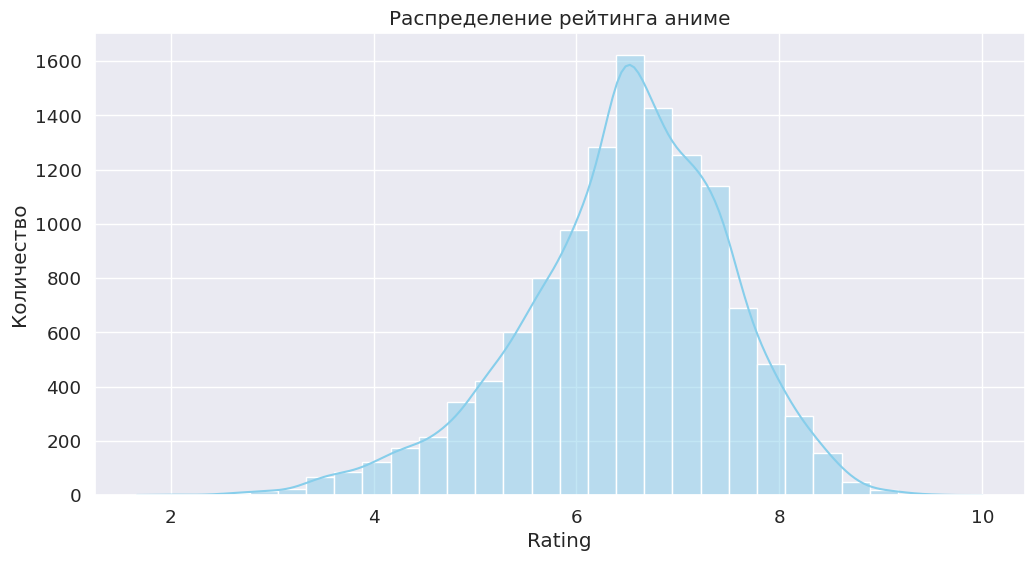

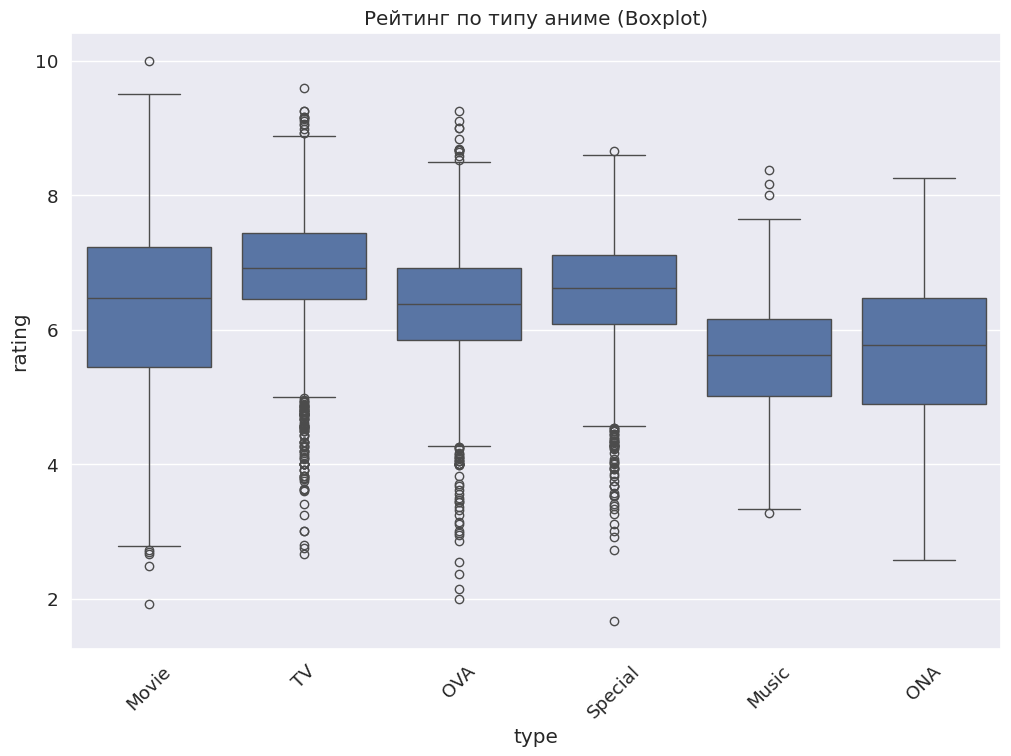

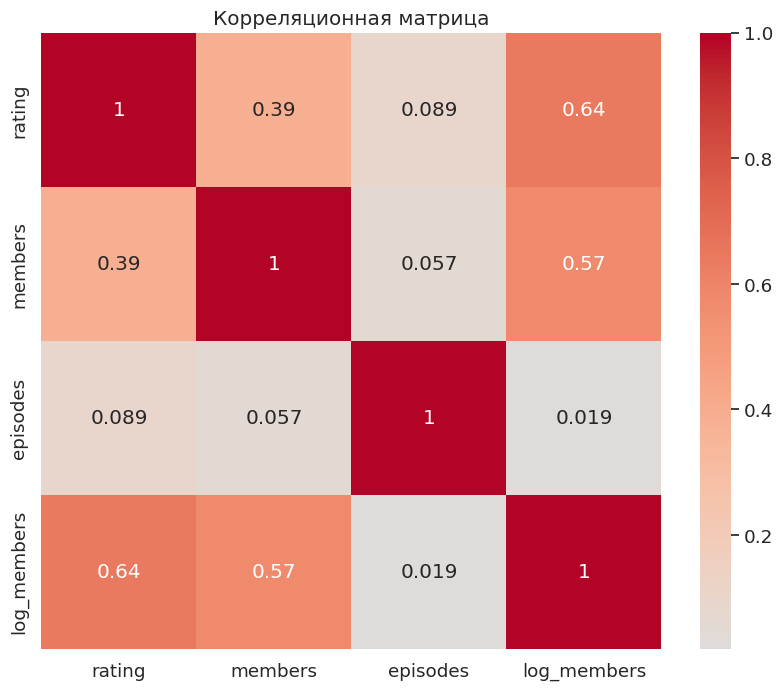

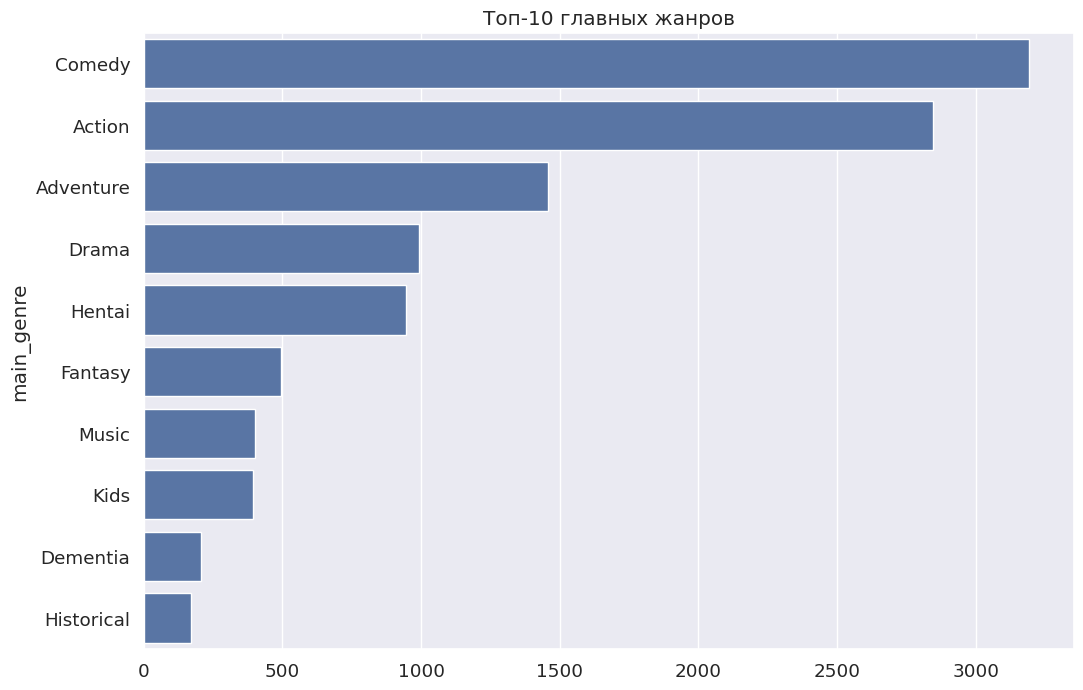


F) Итоговые выводы

Что я понял про датасет:

1. Средний рейтинг аниме ≈ 6.5–7.0 (но есть выдающиеся хиты >9.0).
2. Большинство аниме — TV-сериалы, фильмы встречаются реже.
3. Пропуски были только в episodes и rating — заполнили медианой и средним (обосновано).
4. Распределение рейтинга слегка скошено влево (много средних аниме).
5. Популярность (members) сильно коррелирует с рейтингом (логарифм помог нормализовать).
6. Главные жанры: Action, Comedy, Drama, Fantasy — самые частые.
7. Есть аномалии: episodes = Unknown → превратили в NaN и заполнили.
8. Новые признаки (log_members, main_genre, is_movie) улучшат будущую модель.

Гипотезы / наблюдения:
• Аниме с типом Movie чаще имеют высокий рейтинг, чем длинные сериалы.
• Жанр "Shounen" и "Seinen" сильно влияют на популярность (members).
• Чем больше участников — тем выше рейтинг (положительная корреляция).

Что делать дальше:
• Построить модель регрессии для предсказания rating.
• Или классификацию: "хит / не хит" по порогу 8.0.
• Доба

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction import FeatureHasher

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
pd.set_option('display.max_columns', None)
sns.set(font_scale=1.2)

print("Библиотеки загружены")
# 1. Загрузка данных
print("1. Загрузка данных")
df = pd.read_csv('/content/anime.csv')
print(f"Размер датасета: {df.shape}")
df.head()
# A) Быстрый обзор данных
print("\nA) Быстрый обзор данных")
print("Первые и последние строки:")
display(df.head(3))
display(df.tail(3))

print("\nИнформация о данных:")
print(df.info())

print("\nСтатистика числовых колонок:")
display(df.describe())

print("\nСтатистика категориальных колонок:")
display(df.describe(include='object'))

print("\nПропущенные значения:")
print(df.isnull().sum())

print("\nДубликаты:", df.duplicated().sum())

print("\nB) Обработка пропусков")

df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')  
median_ep = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_ep)
print(f"Заполнили пропуски в episodes медианой = {median_ep}")

df['rating'] = df['rating'].fillna(df['rating'].mean())
print(f"Заполнили rating средним = {df['rating'].mean():.2f}")


print("Пропуски после обработки:")
print(df.isnull().sum())
print("\nC) Расширенная статистика")

numeric_cols = ['rating', 'members', 'episodes']

print("Основные статистики:")
for col in numeric_cols:
    print(f"\n--- {col} ---")
    print(f"min: {df[col].min():.2f}")
    print(f"max: {df[col].max():.2f}")
    print(f"mean: {df[col].mean():.2f}")
    print(f"median: {df[col].median():.2f}")
    print(f"mode: {df[col].mode()[0]:.2f}")
    print(f"5% percentile: {df[col].quantile(0.05):.2f}")
    print(f"95% percentile: {df[col].quantile(0.95):.2f}")

print("\nДополнительные метрики (самостоятельно изучил):")
print("Дисперсия (variance):", df['rating'].var())
print("Асимметрия (skewness):", df['rating'].skew())      
print("Эксцесс (kurtosis):", df['rating'].kurt())      

print("\nD) Feature Engineering и кодирование")

# 1. Новый признак: log_members (логарифм популярности)
df['log_members'] = np.log1p(df['members'])

# 2. Новый признак: main_genre (первый жанр из списка)
df['main_genre'] = df['genre'].str.split(',').str[0].str.strip()

# 3. Новый признак: is_movie (1 если тип Movie)
df['is_movie'] = (df['type'] == 'Movie').astype(int)

print("Созданы новые признаки: log_members, main_genre, is_movie")

# One-Hot Encoding для type и main_genre
df_encoded = pd.get_dummies(df, columns=['type', 'main_genre'], drop_first=True)
print(f"После One-Hot Encoding размер: {df_encoded.shape}")

# Label Encoding для примера
le = LabelEncoder()
df['main_genre_encoded'] = le.fit_transform(df['main_genre'].fillna('Unknown'))
# E) Визуализация
print("\nE) Визуализация")

# 1. Распределение рейтинга (matplotlib + seaborn)
plt.figure(figsize=(12,6))
sns.histplot(df['rating'], kde=True, bins=30, color='skyblue')
plt.title('Распределение рейтинга аниме')
plt.xlabel('Rating')
plt.ylabel('Количество')
plt.show()

# 2. Boxplot рейтинга по типу (seaborn)
sns.boxplot(x='type', y='rating', data=df)
plt.title('Рейтинг по типу аниме (Boxplot)')
plt.xticks(rotation=45)
plt.show()

# 3. Scatter plot: members vs rating (Plotly — интерактивный!)
fig = px.scatter(df, x='members', y='rating', hover_data=['name'],
                 title='Популярность vs Рейтинг (наведите на точки!)',
                 log_x=True)
fig.show()

# 4. Heatmap корреляций
plt.figure(figsize=(10,8))
corr = df[numeric_cols + ['log_members']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

# 5. Топ-10 жанров (barplot)
top_genres = df['main_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title('Топ-10 главных жанров')
plt.show()
# F) Итоговые выводы
print("\nF) Итоговые выводы")
print("""
Что я понял про датасет:

1. Средний рейтинг аниме ≈ 6.5–7.0 (но есть выдающиеся хиты >9.0).
2. Большинство аниме — TV-сериалы, фильмы встречаются реже.
3. Пропуски были только в episodes и rating — заполнили медианой и средним (обосновано).
4. Распределение рейтинга слегка скошено влево (много средних аниме).
5. Популярность (members) сильно коррелирует с рейтингом (логарифм помог нормализовать).
6. Главные жанры: Action, Comedy, Drama, Fantasy — самые частые.
7. Есть аномалии: episodes = Unknown → превратили в NaN и заполнили.
8. Новые признаки (log_members, main_genre, is_movie) улучшат будущую модель.

Гипотезы / наблюдения:
- Аниме с типом Movie чаще имеют высокий рейтинг, чем длинные сериалы.
- Жанр "Shounen" и "Seinen" сильно влияют на популярность (members).
- Чем больше участников — тем выше рейтинг (положительная корреляция).
""")

# New Section